In [1]:
# Standard library
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent.parent))


# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook display settings
pd.set_option("display.max_columns", None)

# Custom utilities
from src.utils.data_check import DataCheck
from src.utils.cleaning import DataCleaner
from src.utils.visualization import Visualizer
from src.utils.insight_service import InsightService

# 1. Data Loading

In [2]:
# Project paths
PROJECT_ROOT = Path().resolve().parent.parent

DATA_PATH = "../../data/raw/austo_automobile1.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)

# Preview dataset
df.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,24,Male,Salaried,Married,Post Graduate,4,No,Yes,Yes,52000,25000,77000,18000,Hatchback
1,28,Male,Salaried,Married,Post Graduate,3,No,Yes,No,68000,0,68000,18000,Hatchback
2,23,Male,Salaried,Married,Graduate,4,Yes,Yes,No,31000,0,31000,18000,Hatchback
3,26,Male,Business,Married,Post Graduate,4,Yes,Yes,Yes,66000,35000,101000,18000,Hatchback
4,28,Male,Business,Married,Post Graduate,4,Yes,No,No,64000,0,64000,18000,Hatchback


# 2. Data Understanding

In this section, we:
- inspect dataset structure
- check data types
- identify missing values
- inspect duplicates
- understand variable distributions

In [3]:
overview = DataCheck.overview(df)

print("Dataset Shape:", overview["shape"])

print("\nMissing Values:")
display(overview["missing_values"])

print("\nMissing Percentage:")
display(overview["missing_percentage"])

print("\nDuplicate Rows:")
print(overview["duplicate_rows"])

print("\nData Types:")
display(overview["dtypes"])

Dataset Shape: (1581, 14)

Missing Values:


Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64


Missing Percentage:


Age                 0.0
Gender              0.0
Profession          0.0
Marital_status      0.0
Education           0.0
No_of_Dependents    0.0
Personal_loan       0.0
House_loan          0.0
Partner_working     0.0
Salary              0.0
Partner_salary      0.0
Total_salary        0.0
Price               0.0
Make                0.0
dtype: float64


Duplicate Rows:
0

Data Types:


Age                  int64
Gender              object
Profession          object
Marital_status      object
Education           object
No_of_Dependents     int64
Personal_loan       object
House_loan          object
Partner_working     object
Salary               int64
Partner_salary       int64
Total_salary         int64
Price                int64
Make                object
dtype: object

In [4]:
DataCheck.summary_stat(df)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1581.0,NaN,NaN,NaN,32.211259,9.125477,22.0,25.0,29.0,38.0,60.0
Gender,1581,2,Male,1252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,1581,2,Salaried,896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_status,1581,2,Married,1443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,1581,2,Post Graduate,985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
No_of_Dependents,1581.0,NaN,NaN,NaN,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Personal_loan,1581,2,Yes,792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
House_loan,1581,2,No,1054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner_working,1581,2,Yes,868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,1581.0,NaN,NaN,NaN,59732.447818,14278.642665,30000.0,51000.0,59000.0,71000.0,90000.0


## Initial Observations

### Findings

- The dataset contains customer demographic and automobile purchasing information.
- The dataset contains both numerical and categorical variables.
- No missing values were identified.
- No duplicate records were detected.
- The dataset appears structurally clean and suitable for analysis.

# 3. Data Cleaning

Although the dataset is already clean, validation and standardization are important
to ensure consistency and reproducibility.

In [5]:
# Apply cleaning pipeline
cleaned_df = DataCleaner.clean(df)

# Validate salary consistency
mismatch = DataCheck.salary_consistency(cleaned_df)

print("Rows after cleaning:", cleaned_df.shape[0])
print("Salary mismatches:", len(mismatch))

cleaned_df.head()

Rows after cleaning: 1581
Salary mismatches: 0


,age,gender,profession,marital_status,education,no_of_dependents,personal_loan,house_loan,partner_working,salary,partner_salary,total_salary,price,make
0,24,Male,Salaried,Married,Post Graduate,4,No,Yes,Yes,52000,25000,77000,18000,Hatchback
1,28,Male,Salaried,Married,Post Graduate,3,No,Yes,No,68000,0,68000,18000,Hatchback
2,23,Male,Salaried,Married,Graduate,4,Yes,Yes,No,31000,0,31000,18000,Hatchback
3,26,Male,Business,Married,Post Graduate,4,Yes,Yes,Yes,66000,35000,101000,18000,Hatchback
4,28,Male,Business,Married,Post Graduate,4,Yes,No,No,64000,0,64000,18000,Hatchback


## Cleaning Observations

### Actions Performed

- Standardized column names
- Enforced numeric and categorical data types
- Standardized binary categorical values
- Validated salary calculations
- Removed duplicate rows

### Result

The dataset required minimal cleaning and was already analysis-ready.

# 4. Univariate Analysis

This section analyzes individual variables independently to understand
their distribution and characteristics.

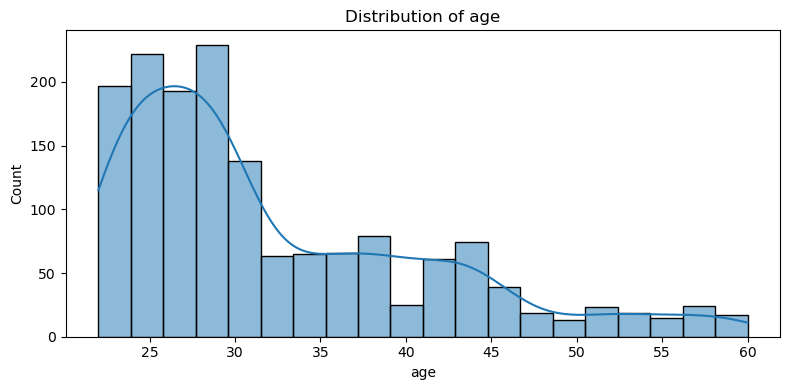

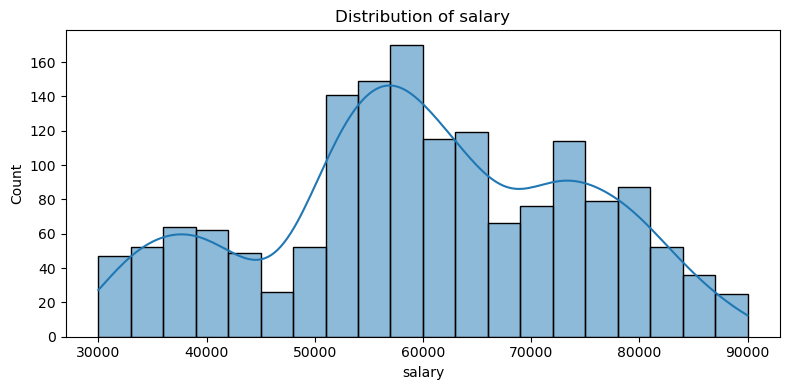

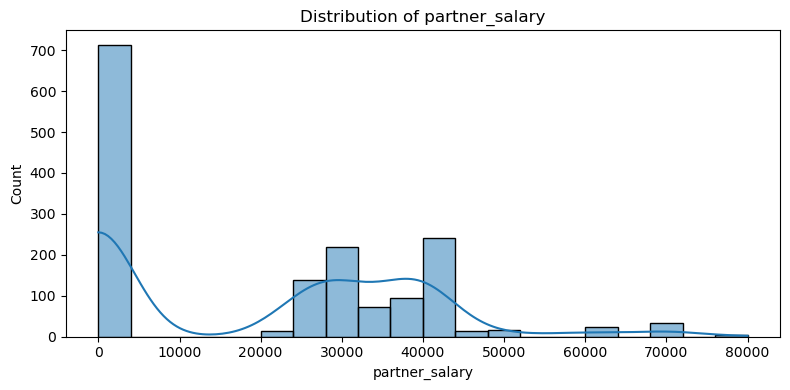

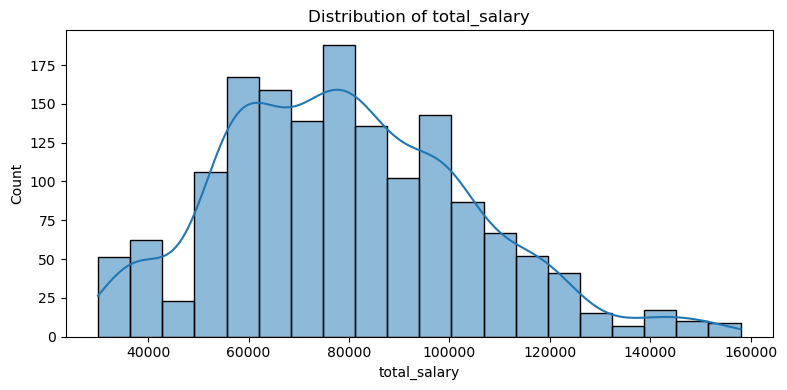

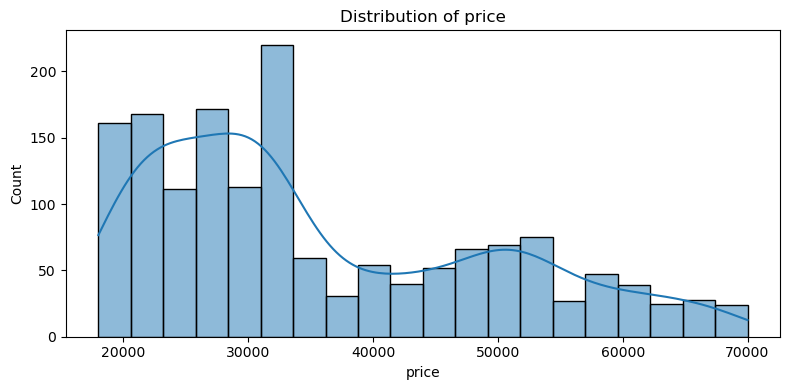

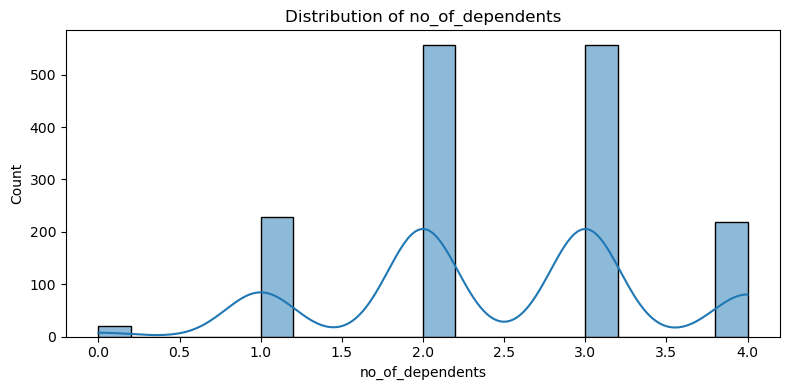

In [6]:
numerical_columns = [
    "age",
    "salary",
    "partner_salary",
    "total_salary",
    "price",
    "no_of_dependents",
]

for col in numerical_columns:
    Visualizer.plot_histogram(cleaned_df, col)

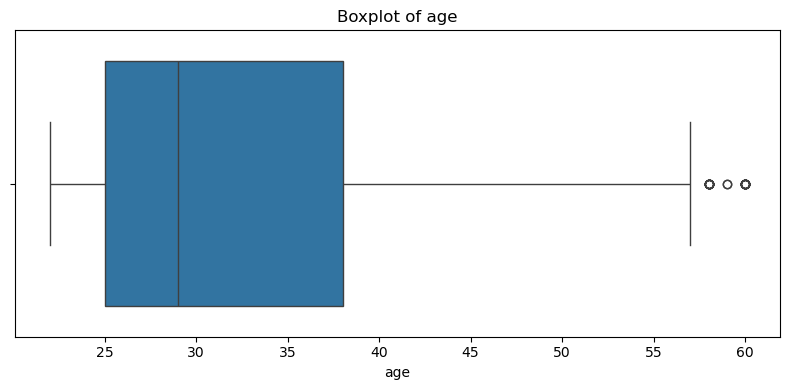

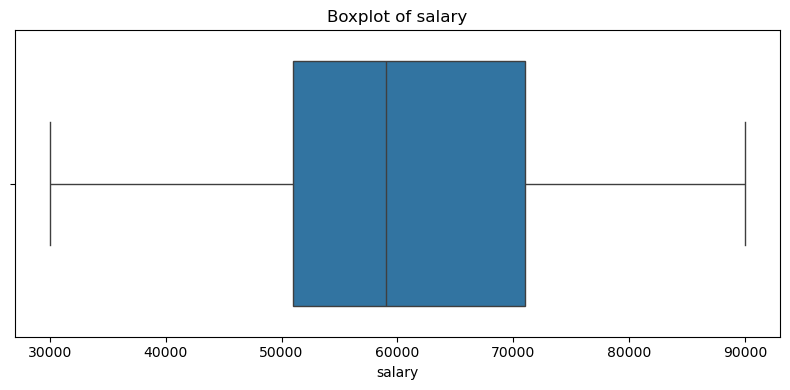

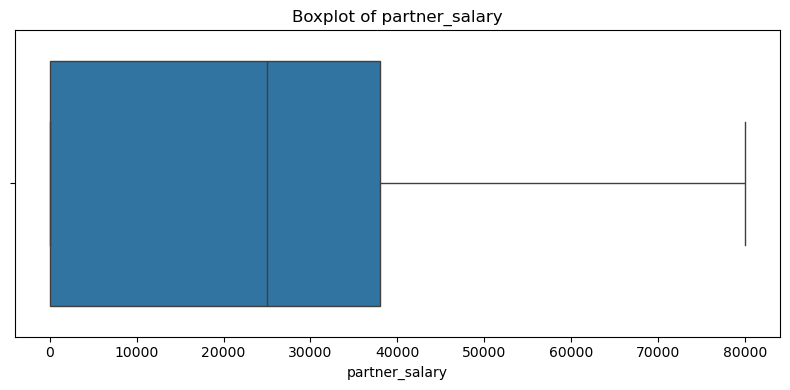

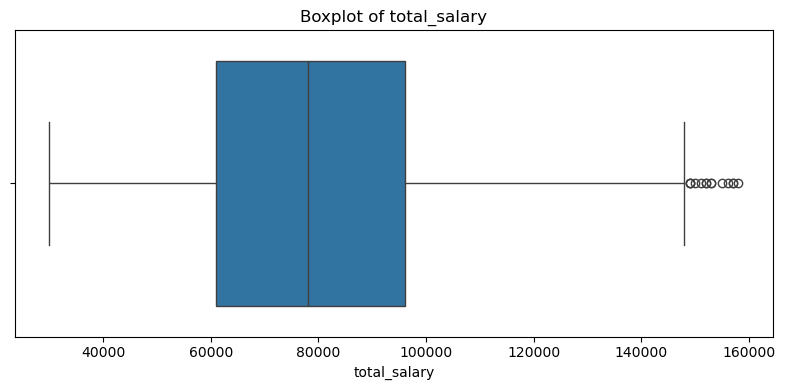

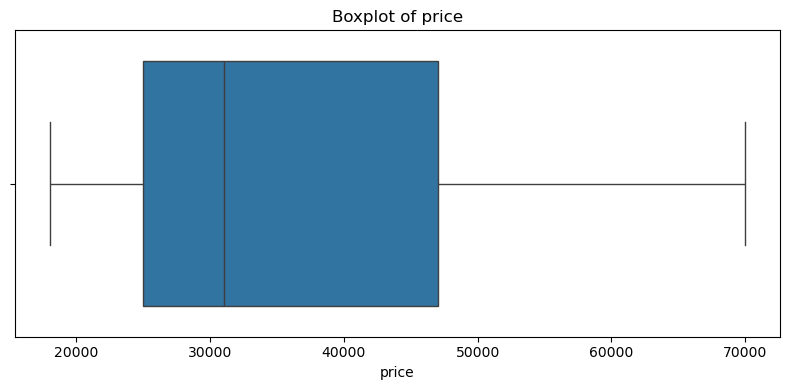

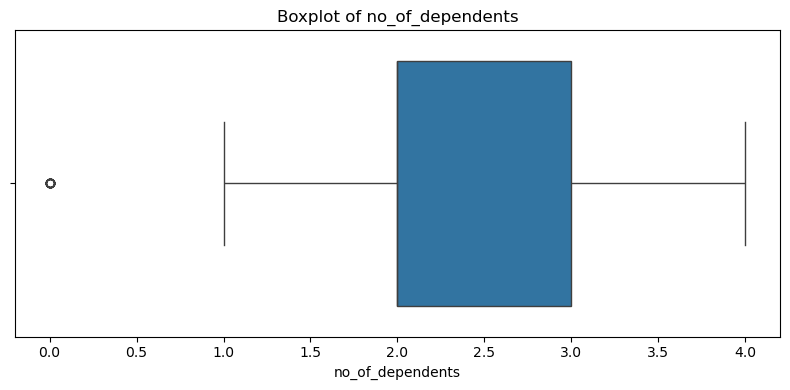

In [7]:
for col in numerical_columns:
    Visualizer.plot_box(cleaned_df, col)

## Univariate Insights

### Key Findings

- Hatchbacks are the most preferred vehicle type.
- SUV purchases are the least common.
- Income variables are right-skewed, indicating income inequality within the sample.
- Most customers fall within the young-to-middle-age category.
- The majority of customers are salaried employees.
- Married customers represent a significant portion of buyers.

# 5. Bivariate Analysis

This section explores relationships between variables and identifies
the factors associated with automobile purchase behavior.

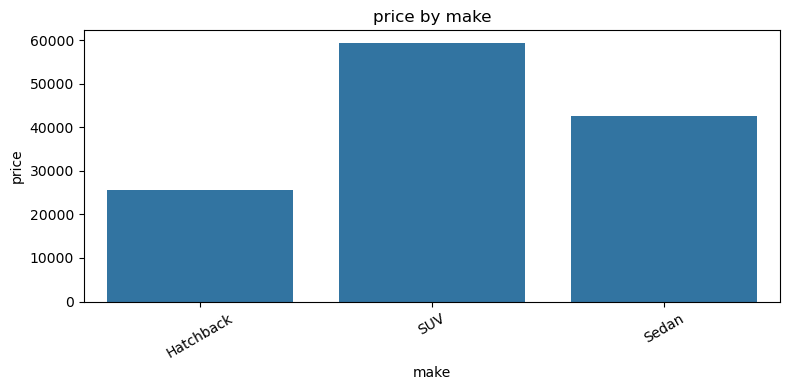

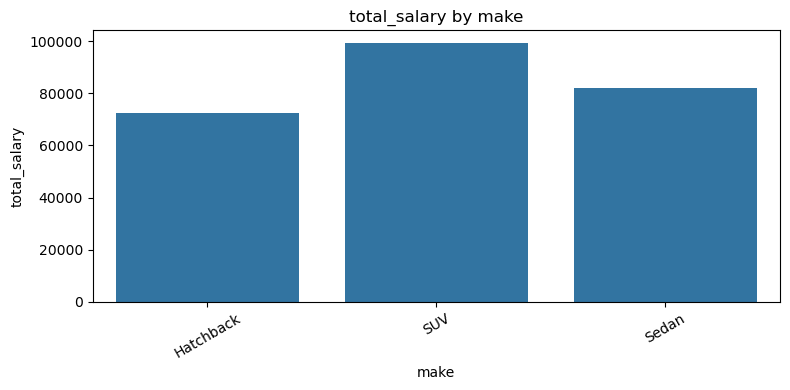

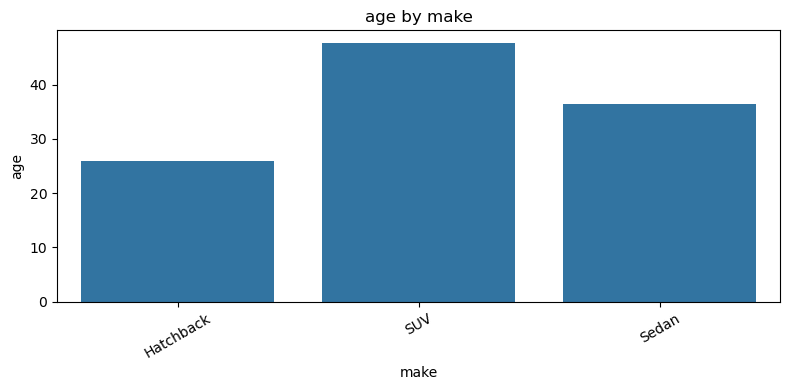

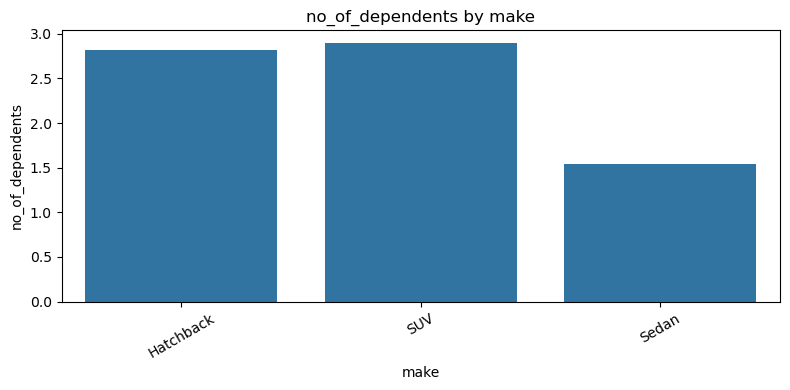

In [9]:
Visualizer.plot_bar(cleaned_df, x="make", y="price")
Visualizer.plot_bar(cleaned_df, x="make", y="total_salary")
Visualizer.plot_bar(cleaned_df, x="make", y="age")
Visualizer.plot_bar(cleaned_df, x="make", y="no_of_dependents")

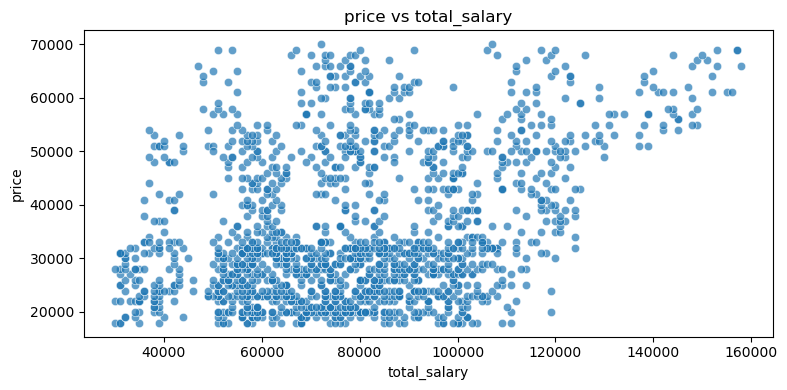

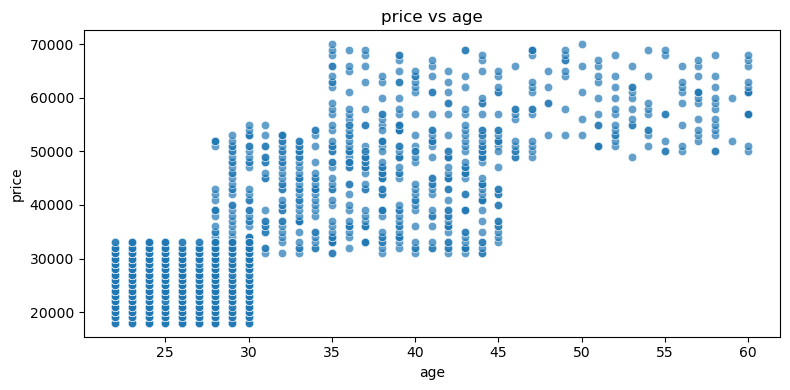

In [10]:
Visualizer.plot_scatter(cleaned_df, x="total_salary", y="price")
Visualizer.plot_scatter(cleaned_df, x="age", y="price")

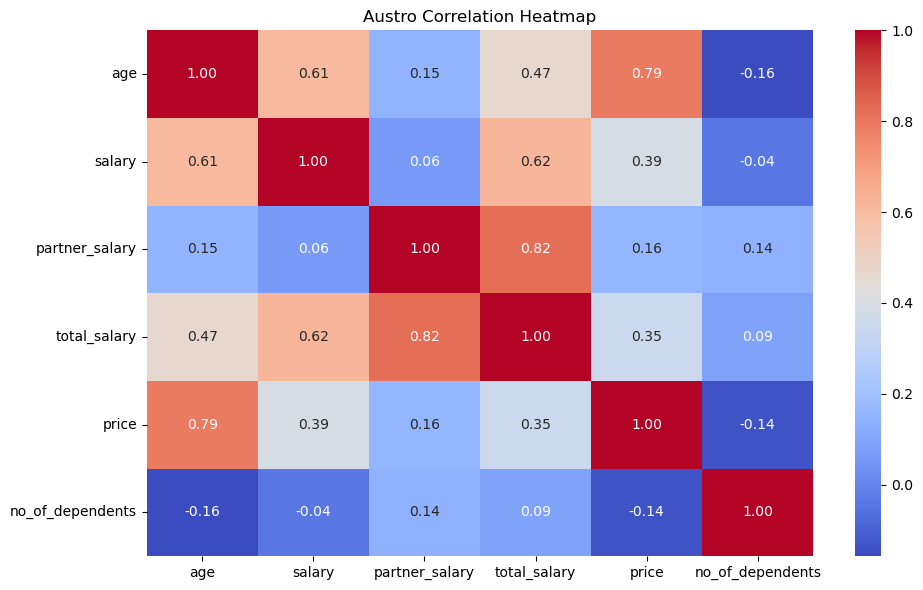

In [11]:
Visualizer.plot_corr_heatmap(
    cleaned_df,
    [
        "age",
        "salary",
        "partner_salary",
        "total_salary",
        "price",
        "no_of_dependents",
    ]
)

In [12]:
InsightService.make_summary(cleaned_df)

,count,avg_age,avg_salary,avg_partner_salary,avg_total_salary,avg_price,avg_dependents
make,,,,,,,
Hatchback,884,25.87,54969.46,17707.01,72676.47,25561.09,2.82
SUV,237,47.60,72683.54,26632.91,99316.46,59303.80,2.89
Sedan,460,36.46,62213.04,20028.26,82241.30,42671.74,1.54


## Bivariate Insights

### Key Findings

1. Household income increases with vehicle price.

2. SUV buyers have the highest average household income.

3. Hatchback buyers tend to be younger customers.

4. Sedan buyers occupy the middle-income and middle-age segment.

5. Older customers are more likely to purchase expensive vehicles.

6. Customers with existing financial obligations appear less likely to purchase SUVs.

7. Income and age are strong segmentation variables for automobile preference.

# 6. Business Recommendations

In [13]:
insights = InsightService.business_insights(cleaned_df)

for idx, insight in enumerate(insights, start=1):
    print(f"{idx}. {insight}")

1. Hatchback is the most preferred car type in the dataset (55.9% of customers), so it is the strongest mass-market segment.
2. SUV buyers are the oldest on average (47.6 years), suggesting life-stage affects purchase choice.
3. SUV buyers have the highest average household income (99,316), which supports premium positioning.
4. SUV has the highest average price (59,304), so it should be targeted to higher-income segments.
5. Customers with a house loan did not purchase SUVs in this dataset, which suggests debt burden is linked to lower vehicle choice.


# 7. Final Business Recommendations

## Recommendation 1 — Focus on Hatchbacks for Mass Market Entry

Hatchbacks dominate the dataset and represent the largest customer segment.
Austo should prioritize affordable and fuel-efficient hatchback models
to maximize market penetration.

---

## Recommendation 2 — Position SUVs as Premium Products

SUV buyers are older and belong to higher-income households.
SUVs should be marketed as premium family-oriented vehicles.

---

## Recommendation 3 — Use Customer Segmentation

Customer demographics such as:
- age
- income
- profession
- household income

should be used for targeted marketing campaigns.

---

## Recommendation 4 — Introduce Financing-Based Marketing Strategies

Customers with existing loans appear more price-sensitive.
Flexible financing plans may improve premium vehicle adoption.

---

## Recommendation 5 — Expand Sedan Positioning

Sedans occupy the middle market and can serve as a transition product
between affordability and premium ownership.

# 8. Conclusion

This analysis explored customer demographics, income levels, and automobile
preferences in the US market.

### Major Conclusions

- Hatchbacks dominate the market.
- SUVs are associated with wealthier and older households.
- Income strongly influences automobile choice.
- Customer segmentation can improve marketing effectiveness.
- Financing obligations influence purchase behavior.

The findings provide Austo with actionable insights to support
market-entry strategy and product positioning in the US automobile market.